# AI Credit Risk & Loan Default Intelligence Platform
### Graduation Project — Full Pipeline (Colab-ready)

This single notebook walks through the entire project:
1. Setup & data download
2. SQL & data pipeline
3. EDA
4. Feature engineering
5. ML track (Logistic Regression → Decision Tree → Random Forest → XGBoost)
6. Deep Learning track (MLP)
7. Explainability (SHAP)
8. Model comparison & saving artifacts for the Streamlit app

> Run cells top to bottom. Sections are independent enough that you can re-run
> individual sections after the data is loaded.


## 0. Setup

In [1]:
# Install dependencies (Colab already has most of these, this just pins versions)
!pip install -q kaggle xgboost shap imbalanced-learn joblib


In [13]:
!mkdir -p ~/.kaggle
!echo "KGAT_00b2e099254bd27fe1ffab2619fee3c4" > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

In [14]:
!kaggle competitions download -c home-credit-default-risk -p data/raw
!unzip -o data/raw/home-credit-default-risk.zip -d data/raw
!rm data/raw/home-credit-default-risk.zip

100% 688M/688M [00:07<00:00, 96.6MB/s]

Archive:  data/raw/home-credit-default-risk.zip
  inflating: data/raw/HomeCredit_columns_description.csv  
  inflating: data/raw/POS_CASH_balance.csv  
  inflating: data/raw/application_test.csv  
  inflating: data/raw/application_train.csv  
  inflating: data/raw/bureau.csv     
  inflating: data/raw/bureau_balance.csv  
  inflating: data/raw/credit_card_balance.csv  
  inflating: data/raw/installments_payments.csv  
  inflating: data/raw/previous_application.csv  
  inflating: data/raw/sample_submission.csv  


In [15]:
!ls -la data/raw/

total 2621396
drwxr-xr-x 2 root root      4096 Sep 16 11:39 .
drwxr-xr-x 3 root root      4096 Sep 16 11:15 ..
-rw-r--r-- 1 root root  26567651 Dec 11  2019 application_test.csv
-rw-r--r-- 1 root root 166133370 Dec 11  2019 application_train.csv
-rw-r--r-- 1 root root 375592889 Dec 11  2019 bureau_balance.csv
-rw-r--r-- 1 root root 170016717 Dec 11  2019 bureau.csv
-rw-r--r-- 1 root root 424582605 Dec 11  2019 credit_card_balance.csv
-rw-r--r-- 1 root root     37383 Dec 11  2019 HomeCredit_columns_description.csv
-rw-r--r-- 1 root root 723118349 Dec 11  2019 installments_payments.csv
-rw-r--r-- 1 root root 392703158 Dec 11  2019 POS_CASH_balance.csv
-rw-r--r-- 1 root root 404973293 Dec 11  2019 previous_application.csv
-rw-r--r-- 1 root root    536202 Dec 11  2019 sample_submission.csv


In [12]:
!kaggle competitions download -c home-credit-default-risk -p data/raw

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFiles


In [16]:
import os
from pathlib import Path

# --- Option A: Kaggle API (recommended) -------------------------------------
# 1. Upload your kaggle.json (Kaggle -> Account -> API -> Create New Token)
# 2. Uncomment the block below and run it once.

# from google.colab import files
# uploaded = files.upload()  # select kaggle.json
# os.makedirs('/root/.kaggle', exist_ok=True)
# import shutil
# shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
# os.chmod('/root/.kaggle/kaggle.json', 0o600)
# !kaggle competitions download -c home-credit-default-risk -p data/raw
# !unzip -o data/raw/home-credit-default-risk.zip -d data/raw

# --- Option B: Manual upload --------------------------------------------
# If you already downloaded the CSVs manually, upload them directly:
# from google.colab import files
# uploaded = files.upload()  # select the CSVs, they will land in the CWD

DATA_DIR = Path("data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)
print("Data directory ready at:", DATA_DIR.resolve())


Data directory ready at: /content/data/raw


In [17]:
import pandas as pd
import numpy as np

EXPECTED_FILES = [
    "application_train.csv", "application_test.csv", "bureau.csv",
    "bureau_balance.csv", "previous_application.csv", "POS_CASH_balance.csv",
    "installments_payments.csv", "credit_card_balance.csv",
]

for f in EXPECTED_FILES:
    path = DATA_DIR / f
    print(f"{f:<32} {'FOUND' if path.exists() else 'MISSING'}")


application_train.csv            FOUND
application_test.csv             FOUND
bureau.csv                       FOUND
bureau_balance.csv               FOUND
previous_application.csv         FOUND
POS_CASH_balance.csv             FOUND
installments_payments.csv        FOUND
credit_card_balance.csv          FOUND


## 1. Load Data

We load the core `application_train` / `application_test` tables plus the
supplementary tables used for feature engineering later.

In [5]:
!ls -la data/raw/

total 8
drwxr-xr-x 2 root root 4096 Sep 16 11:15 .
drwxr-xr-x 3 root root 4096 Sep 16 11:15 ..


In [18]:
app_train = pd.read_csv(DATA_DIR / "application_train.csv")
app_test  = pd.read_csv(DATA_DIR / "application_test.csv")
bureau    = pd.read_csv(DATA_DIR / "bureau.csv")
bureau_balance = pd.read_csv(DATA_DIR / "bureau_balance.csv")
prev_app  = pd.read_csv(DATA_DIR / "previous_application.csv")
pos_cash  = pd.read_csv(DATA_DIR / "POS_CASH_balance.csv")
installments = pd.read_csv(DATA_DIR / "installments_payments.csv")
credit_card  = pd.read_csv(DATA_DIR / "credit_card_balance.csv")

print("app_train:", app_train.shape)
print("app_test :", app_test.shape)
print("bureau   :", bureau.shape)
print("prev_app :", prev_app.shape)
app_train.head()


app_train: (307511, 122)
app_test : (48744, 121)
bureau   : (1716428, 17)
prev_app : (1670214, 37)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. SQL & Data Pipeline

We load the tables into an in-memory SQLite database and run at least 10
analytical queries (JOINs, CTEs, window functions) as required by the
roadmap. This also doubles as a lightweight, reproducible ETL layer.

In [19]:
import sqlite3

conn = sqlite3.connect(":memory:")
app_train.to_sql("application_train", conn, index=False, if_exists="replace")
bureau.to_sql("bureau", conn, index=False, if_exists="replace")
prev_app.to_sql("previous_application", conn, index=False, if_exists="replace")
installments.to_sql("installments_payments", conn, index=False, if_exists="replace")

def q(sql):
    return pd.read_sql_query(sql, conn)


In [20]:
# Query 1: Default rate overall
q("""
SELECT
  COUNT(*) AS total_applicants,
  SUM(TARGET) AS defaulters,
  ROUND(100.0 * SUM(TARGET) / COUNT(*), 2) AS default_rate_pct
FROM application_train
""")


,total_applicants,defaulters,default_rate_pct
0,307511,24825,8.07


In [21]:
# Query 2: Default rate by income type (GROUP BY)
q("""
SELECT NAME_INCOME_TYPE,
       COUNT(*) AS n,
       ROUND(100.0 * SUM(TARGET) / COUNT(*), 2) AS default_rate_pct
FROM application_train
GROUP BY NAME_INCOME_TYPE
ORDER BY default_rate_pct DESC
""")


,NAME_INCOME_TYPE,n,default_rate_pct
0,Maternity leave,5,40.00
1,Unemployed,22,36.36
2,Working,158774,9.59
3,Commercial associate,71617,7.48
4,State servant,21703,5.75
5,Pensioner,55362,5.39
6,Student,18,0.00
7,Businessman,10,0.00


In [22]:
# Query 3: Default rate by education level
q("""
SELECT NAME_EDUCATION_TYPE,
       COUNT(*) AS n,
       ROUND(AVG(AMT_INCOME_TOTAL), 0) AS avg_income,
       ROUND(100.0 * SUM(TARGET) / COUNT(*), 2) AS default_rate_pct
FROM application_train
GROUP BY NAME_EDUCATION_TYPE
ORDER BY default_rate_pct DESC
""")


,NAME_EDUCATION_TYPE,n,avg_income,default_rate_pct
0,Lower secondary,3816,130079.0,10.93
1,Secondary / secondary special,218391,155159.0,8.94
2,Incomplete higher,10277,181564.0,8.48
3,Higher education,74863,208652.0,5.36
4,Academic degree,164,240009.0,1.83


In [23]:
# Query 4: JOIN — applicants with their bureau credit history count
q("""
SELECT a.SK_ID_CURR, a.TARGET, COUNT(b.SK_ID_BUREAU) AS n_bureau_credits
FROM application_train a
LEFT JOIN bureau b ON a.SK_ID_CURR = b.SK_ID_CURR
GROUP BY a.SK_ID_CURR, a.TARGET
LIMIT 20
""")


,SK_ID_CURR,TARGET,n_bureau_credits
0,100002,1,8
1,100003,0,4
2,100004,0,2
3,100006,0,0
4,100007,0,1
5,100008,0,3
6,100009,0,18
7,100010,0,2
8,100011,0,4
9,100012,0,0


In [24]:
# Query 5: Applicants with overdue bureau credit (JOIN + WHERE)
q("""
SELECT a.SK_ID_CURR, a.TARGET, b.CREDIT_ACTIVE, b.AMT_CREDIT_SUM_OVERDUE
FROM application_train a
JOIN bureau b ON a.SK_ID_CURR = b.SK_ID_CURR
WHERE b.AMT_CREDIT_SUM_OVERDUE > 0
LIMIT 20
""")


,SK_ID_CURR,TARGET,CREDIT_ACTIVE,AMT_CREDIT_SUM_OVERDUE
0,282297,0,Active,231.525
1,408647,0,Active,288.000
2,380677,0,Active,58.500
3,218135,0,Active,504.000
4,229323,0,Active,169582.500
5,295460,0,Active,36.000
6,295460,0,Active,540.000
7,129289,0,Active,58.500
8,446640,1,Active,1710.000
9,446640,1,Active,4941.000


In [25]:
# Query 6: CTE — average previous application amount per applicant
q("""
WITH prev_agg AS (
  SELECT SK_ID_CURR, AVG(AMT_APPLICATION) AS avg_prev_amt, COUNT(*) AS n_prev
  FROM previous_application
  GROUP BY SK_ID_CURR
)
SELECT a.SK_ID_CURR, a.TARGET, p.avg_prev_amt, p.n_prev
FROM application_train a
JOIN prev_agg p ON a.SK_ID_CURR = p.SK_ID_CURR
ORDER BY p.n_prev DESC
LIMIT 20
""")


,SK_ID_CURR,TARGET,avg_prev_amt,n_prev
0,265681,0,172251.801370,73
1,173680,0,113228.375000,72
2,242412,0,216069.959779,68
3,206783,0,197149.365672,67
4,382179,0,109220.695312,64
5,389950,0,9122.273438,64
6,198355,0,173568.785714,63
7,345161,0,341070.169355,62
8,446486,0,20132.491935,62
9,238250,0,109400.163934,61


In [26]:
# Query 7: Window function — rank applicants by income within each family status
q("""
SELECT SK_ID_CURR, NAME_FAMILY_STATUS, AMT_INCOME_TOTAL,
       RANK() OVER (PARTITION BY NAME_FAMILY_STATUS ORDER BY AMT_INCOME_TOTAL DESC) AS income_rank
FROM application_train
LIMIT 20
""")


,SK_ID_CURR,NAME_FAMILY_STATUS,AMT_INCOME_TOTAL,income_rank
0,190160,Civil marriage,9000000.0,1
1,123587,Civil marriage,3825000.0,2
2,387126,Civil marriage,3150000.0,3
3,304300,Civil marriage,2025000.0,4
4,410465,Civil marriage,1665000.0,5
5,363367,Civil marriage,1575000.0,6
6,370371,Civil marriage,1575000.0,6
7,396363,Civil marriage,1381500.0,8
8,128538,Civil marriage,1350000.0,9
9,191640,Civil marriage,1350000.0,9


In [27]:
# Query 8: Window function — running default rate ordered by income (deciles)
q("""
SELECT SK_ID_CURR, AMT_INCOME_TOTAL, TARGET,
       NTILE(10) OVER (ORDER BY AMT_INCOME_TOTAL) AS income_decile
FROM application_train
LIMIT 20
""")


,SK_ID_CURR,AMT_INCOME_TOTAL,TARGET,income_decile
0,101965,25650.0,0,1
1,124157,25650.0,1,1
2,316377,26100.0,0,1
3,378118,26100.0,0,1
4,384810,26100.0,0,1
5,253920,26460.0,0,1
6,303289,26550.0,0,1
7,404212,26550.0,0,1
8,103644,27000.0,0,1
9,105387,27000.0,0,1


In [28]:
# Query 9: Installments — late payment ratio per applicant (aggregation)
q("""
SELECT SK_ID_CURR,
       COUNT(*) AS n_installments,
       SUM(CASE WHEN DAYS_ENTRY_PAYMENT > DAYS_INSTALMENT THEN 1 ELSE 0 END) AS n_late,
       ROUND(100.0 * SUM(CASE WHEN DAYS_ENTRY_PAYMENT > DAYS_INSTALMENT THEN 1 ELSE 0 END) / COUNT(*), 2) AS late_pct
FROM installments_payments
GROUP BY SK_ID_CURR
ORDER BY late_pct DESC
LIMIT 20
""")


,SK_ID_CURR,n_installments,n_late,late_pct
0,455019,12,12,100.0
1,451457,4,4,100.0
2,443155,4,4,100.0
3,441240,12,12,100.0
4,437326,9,9,100.0
5,435234,1,1,100.0
6,433263,1,1,100.0
7,429485,10,10,100.0
8,422280,23,23,100.0
9,417820,4,4,100.0


In [29]:
# Query 10: Combined risk view — bureau overdue + late installments + target
q("""
WITH bureau_overdue AS (
  SELECT SK_ID_CURR, SUM(AMT_CREDIT_SUM_OVERDUE) AS total_overdue
  FROM bureau GROUP BY SK_ID_CURR
),
late_pay AS (
  SELECT SK_ID_CURR,
         SUM(CASE WHEN DAYS_ENTRY_PAYMENT > DAYS_INSTALMENT THEN 1 ELSE 0 END) AS n_late
  FROM installments_payments GROUP BY SK_ID_CURR
)
SELECT a.SK_ID_CURR, a.TARGET,
       COALESCE(bo.total_overdue, 0) AS total_overdue,
       COALESCE(lp.n_late, 0) AS n_late_payments
FROM application_train a
LEFT JOIN bureau_overdue bo ON a.SK_ID_CURR = bo.SK_ID_CURR
LEFT JOIN late_pay lp ON a.SK_ID_CURR = lp.SK_ID_CURR
ORDER BY total_overdue DESC
LIMIT 20
""")


,SK_ID_CURR,TARGET,total_overdue,n_late_payments
0,355093,0,3756681.000,0
1,435405,0,3681063.000,0
2,427996,0,2901294.000,8
3,121845,1,2387232.000,1
4,142384,0,2079509.895,1
5,264144,1,1958260.500,0
6,420080,0,1851210.000,7
7,174099,0,1617403.500,4
8,226707,0,1361214.000,11
9,266765,0,1224474.885,10


## 3. Exploratory Data Analysis (EDA)

In [30]:
# Missing values overview
missing = app_train.isnull().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]
print(f"{len(missing)} columns have missing values")
missing.head(20)


67 columns have missing values


,0
COMMONAREA_AVG,69.872297
COMMONAREA_MODE,69.872297
COMMONAREA_MEDI,69.872297
NONLIVINGAPARTMENTS_MEDI,69.432963
NONLIVINGAPARTMENTS_MODE,69.432963
NONLIVINGAPARTMENTS_AVG,69.432963
FONDKAPREMONT_MODE,68.386172
LIVINGAPARTMENTS_AVG,68.354953
LIVINGAPARTMENTS_MEDI,68.354953
LIVINGAPARTMENTS_MODE,68.354953


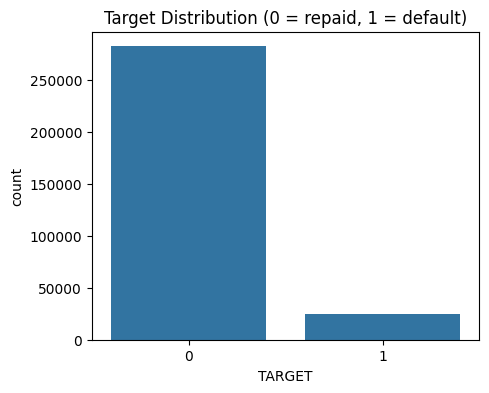

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target imbalance
plt.figure(figsize=(5,4))
sns.countplot(x="TARGET", data=app_train)
plt.title("Target Distribution (0 = repaid, 1 = default)")
plt.show()

print(app_train["TARGET"].value_counts(normalize=True) * 100)


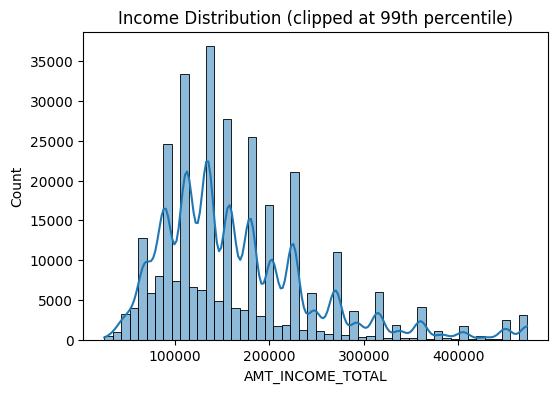

In [32]:
# Univariate: income distribution (clipped for readability)
plt.figure(figsize=(6,4))
sns.histplot(app_train["AMT_INCOME_TOTAL"].clip(upper=app_train["AMT_INCOME_TOTAL"].quantile(0.99)), bins=50, kde=True)
plt.title("Income Distribution (clipped at 99th percentile)")
plt.show()


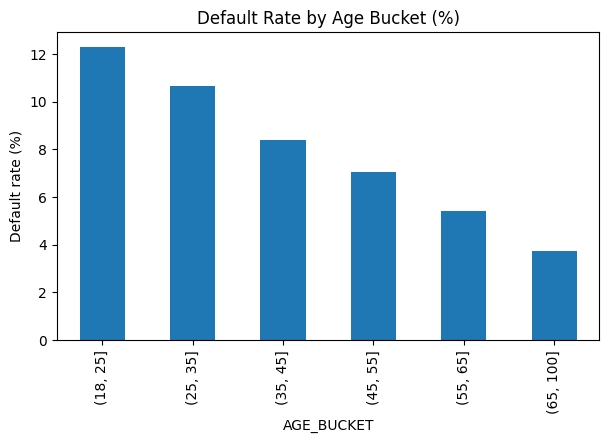

In [33]:
# Bivariate: target-focused — default rate by age bucket
app_train["AGE_YEARS"] = -app_train["DAYS_BIRTH"] / 365
app_train["AGE_BUCKET"] = pd.cut(app_train["AGE_YEARS"], bins=[18,25,35,45,55,65,100])

default_by_age = app_train.groupby("AGE_BUCKET", observed=True)["TARGET"].mean() * 100
default_by_age.plot(kind="bar", figsize=(7,4), title="Default Rate by Age Bucket (%)")
plt.ylabel("Default rate (%)")
plt.show()


In [34]:
# Correlation of top numeric features with TARGET
numeric_cols = app_train.select_dtypes(include=[np.number]).columns
correlations = app_train[numeric_cols].corr()["TARGET"].sort_values()
print("Top negative correlations:")
print(correlations.head(10))
print("\nTop positive correlations:")
print(correlations.tail(10))


Top negative correlations:
EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
AGE_YEARS                    -0.078239
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
REGION_POPULATION_RELATIVE   -0.037227
Name: TARGET, dtype: float64

Top positive correlations:
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, dtype: float64


**Leakage check:** none of the supplementary tables (bureau, previous
applications, installments, credit card, POS cash) contain post-loan-outcome
fields for the *current* loan — they describe history *prior to* this
application, which is safe to use. `SK_ID_CURR` is the join key; no target
leakage columns (e.g. actual default flags of the current loan) exist outside
`application_train.TARGET`.

## 4. Feature Engineering

We aggregate the supplementary tables into applicant-level features and
merge them onto `application_train` / `application_test`.

In [35]:
def aggregate_bureau(bureau_df):
    agg = bureau_df.groupby("SK_ID_CURR").agg(
        bureau_count=("SK_ID_BUREAU", "count"),
        bureau_active_count=("CREDIT_ACTIVE", lambda x: (x == "Active").sum()),
        bureau_overdue_sum=("AMT_CREDIT_SUM_OVERDUE", "sum"),
        bureau_credit_sum=("AMT_CREDIT_SUM", "sum"),
        bureau_debt_sum=("AMT_CREDIT_SUM_DEBT", "sum"),
        bureau_days_credit_mean=("DAYS_CREDIT", "mean"),
    ).reset_index()
    return agg

def aggregate_previous_app(prev_df):
    agg = prev_df.groupby("SK_ID_CURR").agg(
        prev_app_count=("SK_ID_PREV", "count"),
        prev_app_amt_mean=("AMT_APPLICATION", "mean"),
        prev_app_credit_mean=("AMT_CREDIT", "mean"),
        prev_app_refused_count=("NAME_CONTRACT_STATUS", lambda x: (x == "Refused").sum()),
    ).reset_index()
    return agg

def aggregate_installments(inst_df):
    inst_df = inst_df.copy()
    inst_df["is_late"] = (inst_df["DAYS_ENTRY_PAYMENT"] > inst_df["DAYS_INSTALMENT"]).astype(int)
    inst_df["payment_ratio"] = inst_df["AMT_PAYMENT"] / inst_df["AMT_INSTALMENT"].replace(0, np.nan)
    agg = inst_df.groupby("SK_ID_CURR").agg(
        installment_count=("SK_ID_PREV", "count"),
        installment_late_count=("is_late", "sum"),
        installment_payment_ratio_mean=("payment_ratio", "mean"),
    ).reset_index()
    agg["installment_late_pct"] = agg["installment_late_count"] / agg["installment_count"] * 100
    return agg

def aggregate_pos_cash(pos_df):
    agg = pos_df.groupby("SK_ID_CURR").agg(
        pos_cash_count=("SK_ID_PREV", "count"),
        pos_cash_dpd_mean=("SK_DPD", "mean"),
        pos_cash_dpd_max=("SK_DPD", "max"),
    ).reset_index()
    return agg

def aggregate_credit_card(cc_df):
    agg = cc_df.groupby("SK_ID_CURR").agg(
        cc_balance_mean=("AMT_BALANCE", "mean"),
        cc_limit_mean=("AMT_CREDIT_LIMIT_ACTUAL", "mean"),
        cc_dpd_max=("SK_DPD", "max"),
    ).reset_index()
    agg["cc_utilization"] = agg["cc_balance_mean"] / agg["cc_limit_mean"].replace(0, np.nan)
    return agg

bureau_agg = aggregate_bureau(bureau)
prev_agg   = aggregate_previous_app(prev_app)
inst_agg   = aggregate_installments(installments)
pos_agg    = aggregate_pos_cash(pos_cash)
cc_agg     = aggregate_credit_card(credit_card)

print("Feature tables built:", bureau_agg.shape, prev_agg.shape, inst_agg.shape, pos_agg.shape, cc_agg.shape)


Feature tables built: (305811, 7) (338857, 5) (339587, 5) (337252, 4) (103558, 5)


In [36]:
def build_features(base_df):
    df = base_df.copy()
    df = df.merge(bureau_agg, on="SK_ID_CURR", how="left")
    df = df.merge(prev_agg,   on="SK_ID_CURR", how="left")
    df = df.merge(inst_agg,   on="SK_ID_CURR", how="left")
    df = df.merge(pos_agg,    on="SK_ID_CURR", how="left")
    df = df.merge(cc_agg,     on="SK_ID_CURR", how="left")

    # Simple domain ratios
    df["credit_income_ratio"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"].replace(0, np.nan)
    df["annuity_income_ratio"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"].replace(0, np.nan)
    df["employed_years"] = -df["DAYS_EMPLOYED"].replace(365243, np.nan) / 365
    df["age_years"] = -df["DAYS_BIRTH"] / 365

    return df

train_feat = build_features(app_train)
test_feat  = build_features(app_test)
print("train_feat:", train_feat.shape)
train_feat.head()


train_feat: (307511, 149)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,pos_cash_dpd_mean,pos_cash_dpd_max,cc_balance_mean,cc_limit_mean,cc_dpd_max,cc_utilization,credit_income_ratio,annuity_income_ratio,employed_years,age_years
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,NaN,NaN,NaN,NaN,2.007889,0.121978,1.745205,25.920548
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,NaN,NaN,NaN,NaN,4.790750,0.132217,3.254795,45.931507
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,NaN,NaN,NaN,NaN,2.000000,0.100000,0.616438,52.180822
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,270000.0,0.0,0.0,2.316167,0.219900,8.326027,52.068493
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,NaN,NaN,NaN,NaN,4.222222,0.179963,8.323288,54.608219


## 5. Preprocessing Pipeline

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

TARGET_COL = "TARGET"
DROP_COLS = ["SK_ID_CURR", TARGET_COL]

y = train_feat[TARGET_COL]
X = train_feat.drop(columns=[c for c in DROP_COLS if c in train_feat.columns])

# Drop ID-like / non-predictive columns already used only for merges
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print(f"{len(numeric_features)} numeric features, {len(categorical_features)} categorical features")

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train:", X_train.shape, "Val:", X_val.shape)
print("Train default rate: {:.2f}%  Val default rate: {:.2f}%".format(
    y_train.mean()*100, y_val.mean()*100))


130 numeric features, 16 categorical features
Train: (246008, 147) Val: (61503, 147)
Train default rate: 8.07%  Val default rate: 8.07%


## 6. Machine Learning Track

Baseline → Decision Tree → Random Forest → XGBoost, with stratified CV,
class-imbalance handling, and business-cost-driven threshold selection.

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                              precision_score, recall_score, brier_score_loss,
                              confusion_matrix, classification_report)
import xgboost as xgb

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

def evaluate_model(name, pipeline, X_tr, y_tr, X_va, y_va):
    pipeline.fit(X_tr, y_tr)
    proba = pipeline.predict_proba(X_va)[:, 1]
    preds = (proba >= 0.5).astype(int)

    metrics = {
        "roc_auc": roc_auc_score(y_va, proba),
        "pr_auc": average_precision_score(y_va, proba),
        "f1": f1_score(y_va, preds),
        "precision": precision_score(y_va, preds),
        "recall": recall_score(y_va, preds),
        "brier": brier_score_loss(y_va, proba),
    }
    results[name] = metrics
    print(f"--- {name} ---")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")
    return pipeline, proba


In [39]:
# 1) Logistic Regression baseline
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])
logreg_model, logreg_proba = evaluate_model("Logistic Regression", logreg_pipeline, X_train, y_train, X_val, y_val)


--- Logistic Regression ---
  roc_auc: 0.7625
  pr_auc: 0.2452
  f1: 0.2728
  precision: 0.1700
  recall: 0.6906
  brier: 0.1968


In [40]:
# 2) Decision Tree
tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=42)),
])
tree_model, tree_proba = evaluate_model("Decision Tree", tree_pipeline, X_train, y_train, X_val, y_val)


--- Decision Tree ---
  roc_auc: 0.7145
  pr_auc: 0.1935
  f1: 0.2392
  precision: 0.1455
  recall: 0.6717
  brier: 0.2078


In [41]:
# 3) Random Forest
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300, max_depth=12, class_weight="balanced",
        n_jobs=-1, random_state=42)),
])
rf_model, rf_proba = evaluate_model("Random Forest", rf_pipeline, X_train, y_train, X_val, y_val)


--- Random Forest ---
  roc_auc: 0.7440
  pr_auc: 0.2248
  f1: 0.2836
  precision: 0.1926
  recall: 0.5378
  brier: 0.1707


In [42]:
# 4) XGBoost (best classical model candidate)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", xgb.XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="auc", random_state=42, n_jobs=-1)),
])
xgb_model, xgb_proba = evaluate_model("XGBoost", xgb_pipeline, X_train, y_train, X_val, y_val)


--- XGBoost ---
  roc_auc: 0.7747
  pr_auc: 0.2720
  f1: 0.3006
  precision: 0.1960
  recall: 0.6447
  brier: 0.1660


### 6.1 Hyperparameter Tuning (best classical model)

A small randomized search over XGBoost hyperparameters, evaluated with
stratified CV on ROC-AUC.

In [43]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "classifier__n_estimators": [200, 400, 600],
    "classifier__max_depth": [4, 6, 8],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "classifier__subsample": [0.7, 0.8, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 1.0],
}

search = RandomizedSearchCV(
    xgb_pipeline, param_distributions=param_dist, n_iter=10,
    scoring="roc_auc", cv=3, random_state=42, n_jobs=-1, verbose=1,
)
search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print("Best CV ROC-AUC:", search.best_score_)

best_xgb_model = search.best_estimator_
best_xgb_proba = best_xgb_model.predict_proba(X_val)[:, 1]
results["XGBoost (tuned)"] = {
    "roc_auc": roc_auc_score(y_val, best_xgb_proba),
    "pr_auc": average_precision_score(y_val, best_xgb_proba),
    "f1": f1_score(y_val, (best_xgb_proba >= 0.5).astype(int)),
    "precision": precision_score(y_val, (best_xgb_proba >= 0.5).astype(int)),
    "recall": recall_score(y_val, (best_xgb_proba >= 0.5).astype(int)),
    "brier": brier_score_loss(y_val, best_xgb_proba),
}


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'classifier__subsample': 0.8, 'classifier__n_estimators': 600, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 0.8}
Best CV ROC-AUC: 0.7659005015780318


### 6.2 Business-Cost-Driven Threshold Selection

Instead of a universal 0.5 cutoff, we pick the threshold that minimizes a
simple cost matrix. Adjust `COST_FN` / `COST_FP` to reflect your institution's
actual cost of a missed default vs. a wrongly rejected good applicant.

Business-optimal threshold: 0.52 (cost=30633)


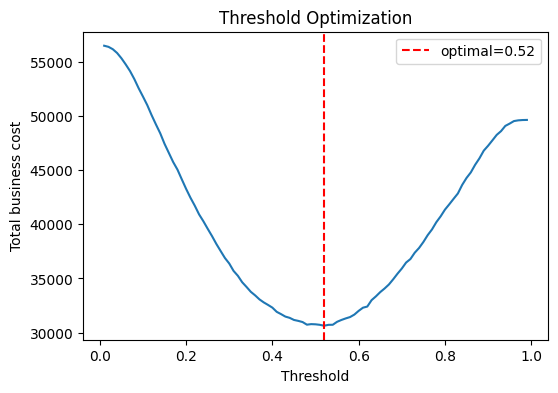

In [44]:
COST_FN = 10  # cost of approving a loan that defaults
COST_FP = 1   # cost of rejecting a good applicant

thresholds = np.linspace(0.01, 0.99, 99)
costs = []
for t in thresholds:
    preds = (best_xgb_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()
    total_cost = fn * COST_FN + fp * COST_FP
    costs.append(total_cost)

best_idx = int(np.argmin(costs))
best_threshold = thresholds[best_idx]
print(f"Business-optimal threshold: {best_threshold:.2f} (cost={costs[best_idx]})")

plt.figure(figsize=(6,4))
plt.plot(thresholds, costs)
plt.axvline(best_threshold, color="red", linestyle="--", label=f"optimal={best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Total business cost")
plt.title("Threshold Optimization")
plt.legend()
plt.show()


## 7. Deep Learning Track — MLP

A meaningful upgrade over the classical models: a Multi-Layer Perceptron on
the same preprocessed tabular features, with early stopping and LR
scheduling.

In [45]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# Reuse the same preprocessor, fit on training data
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)

n_features = X_train_proc.shape[1]
print("Processed feature count:", n_features)

def build_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc"), keras.metrics.AUC(name="pr_auc", curve="PR")],
    )
    return model

mlp = build_mlp(n_features)
mlp.summary()


Processed feature count: 270


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        69,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,129 (438.00 KB)

 Trainable params: 111,361 (435.00 KB)

 Non-trainable params: 768 (3.00 KB)

In [46]:
class_weight = {0: 1.0, 1: float(scale_pos_weight)}

early_stop = callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True)
reduce_lr  = callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=3)

history = mlp.fit(
    X_train_proc, y_train,
    validation_data=(X_val_proc, y_val),
    epochs=50,
    batch_size=512,
    class_weight=class_weight,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)


Epoch 1/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - auc: 0.7064 - loss: 1.1799 - pr_auc: 0.1700 - val_auc: 0.7572 - val_loss: 0.5875 - val_pr_auc: 0.2397 - learning_rate: 0.0010
Epoch 2/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - auc: 0.7479 - loss: 1.0950 - pr_auc: 0.2172 - val_auc: 0.7607 - val_loss: 0.5756 - val_pr_auc: 0.2468 - learning_rate: 0.0010
Epoch 3/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - auc: 0.7565 - loss: 1.0800 - pr_auc: 0.2259 - val_auc: 0.7636 - val_loss: 0.5760 - val_pr_auc: 0.2520 - learning_rate: 0.0010
Epoch 4/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - auc: 0.7620 - loss: 1.0701 - pr_auc: 0.2344 - val_auc: 0.7648 - val_loss: 0.5668 - val_pr_auc: 0.2520 - learning_rate: 0.0010
Epoch 5/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - auc: 0.7648 - loss: 1.0641 - pr_auc: 0.2366 - val_auc: 0.7644 - val_loss: 0.5586 - val_pr_auc: 0.2533 - learning_rate: 0.0010
Epoch 6/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - auc: 0.7685 - loss: 1.0588 - pr_auc: 0.2392 

In [47]:
mlp_proba = mlp.predict(X_val_proc).ravel()
mlp_preds = (mlp_proba >= 0.5).astype(int)

results["MLP (Deep Learning)"] = {
    "roc_auc": roc_auc_score(y_val, mlp_proba),
    "pr_auc": average_precision_score(y_val, mlp_proba),
    "f1": f1_score(y_val, mlp_preds),
    "precision": precision_score(y_val, mlp_preds),
    "recall": recall_score(y_val, mlp_preds),
    "brier": brier_score_loss(y_val, mlp_proba),
}
print(results["MLP (Deep Learning)"])


1922/1922 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
{'roc_auc': np.float64(0.7678625649275018), 'pr_auc': np.float64(0.2576024148676994), 'f1': 0.27101554443723025, 'precision': 0.16721651428032802, 'recall': 0.71460221550856, 'brier': np.float64(0.18899296627939385)}


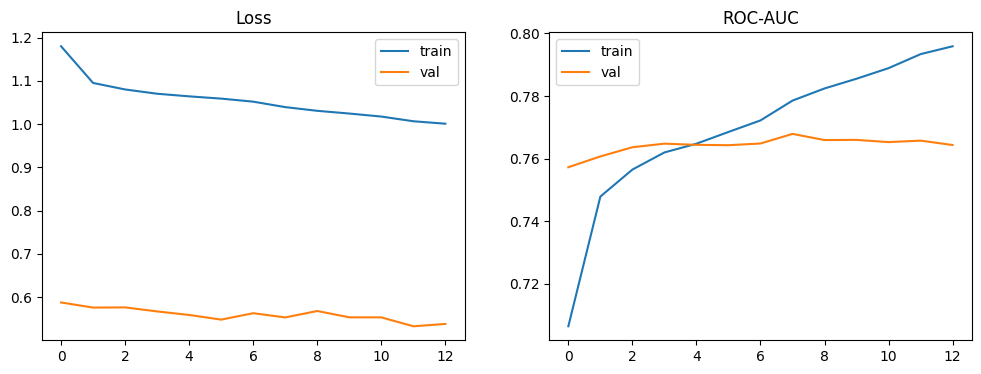

In [48]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(history.history["auc"], label="train")
axes[1].plot(history.history["val_auc"], label="val")
axes[1].set_title("ROC-AUC"); axes[1].legend()
plt.show()


## 8. Model Comparison — Classical ML vs Deep Learning

In [49]:
comparison_df = pd.DataFrame(results).T.sort_values("roc_auc", ascending=False)
comparison_df.style.background_gradient(cmap="Greens", subset=["roc_auc", "pr_auc", "f1"])


,roc_auc,pr_auc,f1,precision,recall,brier
XGBoost (tuned),0.776640,0.273951,0.293886,0.188344,0.668479,0.174229
XGBoost,0.774693,0.272014,0.300648,0.196032,0.644713,0.166008
MLP (Deep Learning),0.767863,0.257602,0.271016,0.167217,0.714602,0.188993
Logistic Regression,0.762463,0.245208,0.272836,0.169997,0.690634,0.196816
Random Forest,0.744042,0.224819,0.283605,0.192585,0.537764,0.170721
Decision Tree,0.714495,0.193490,0.239222,0.145525,0.671702,0.207788


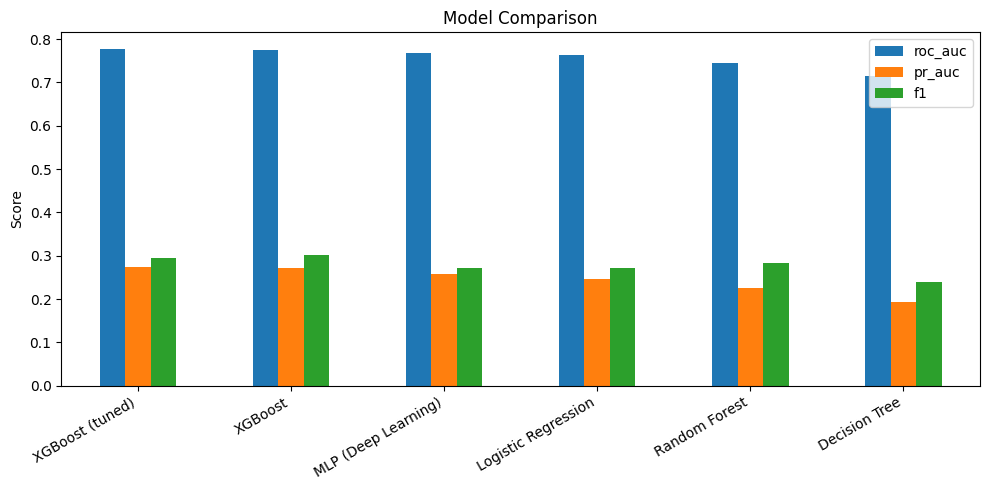

In [50]:
comparison_df.plot(y=["roc_auc", "pr_auc", "f1"], kind="bar", figsize=(10,5), title="Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 9. Explainability — SHAP

Local and global explanations for the best classical model (XGBoost).

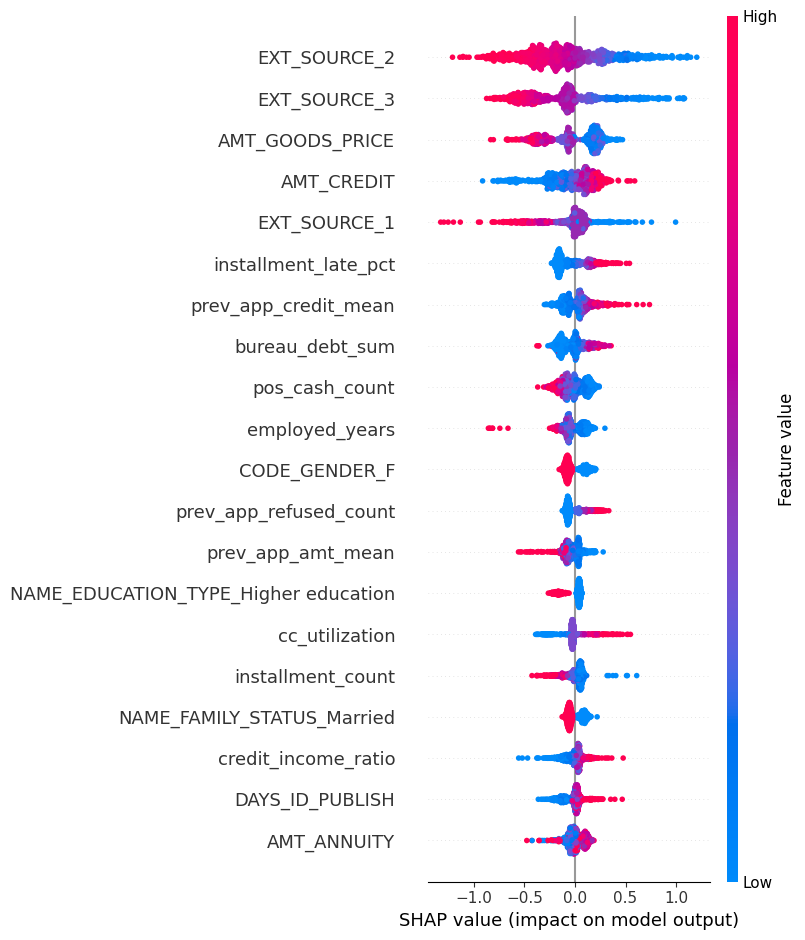

In [51]:
import shap

# Use a sample for speed
sample_idx = np.random.choice(X_val.shape[0], size=min(1000, X_val.shape[0]), replace=False)
X_val_sample = X_val.iloc[sample_idx]
X_val_sample_proc = best_xgb_model.named_steps["preprocessor"].transform(X_val_sample)

explainer = shap.TreeExplainer(best_xgb_model.named_steps["classifier"])
shap_values = explainer.shap_values(X_val_sample_proc)

feature_names = (
    numeric_features +
    list(best_xgb_model.named_steps["preprocessor"]
         .named_transformers_["cat"].named_steps["onehot"]
         .get_feature_names_out(categorical_features))
)

shap.summary_plot(shap_values, X_val_sample_proc, feature_names=feature_names, show=True)


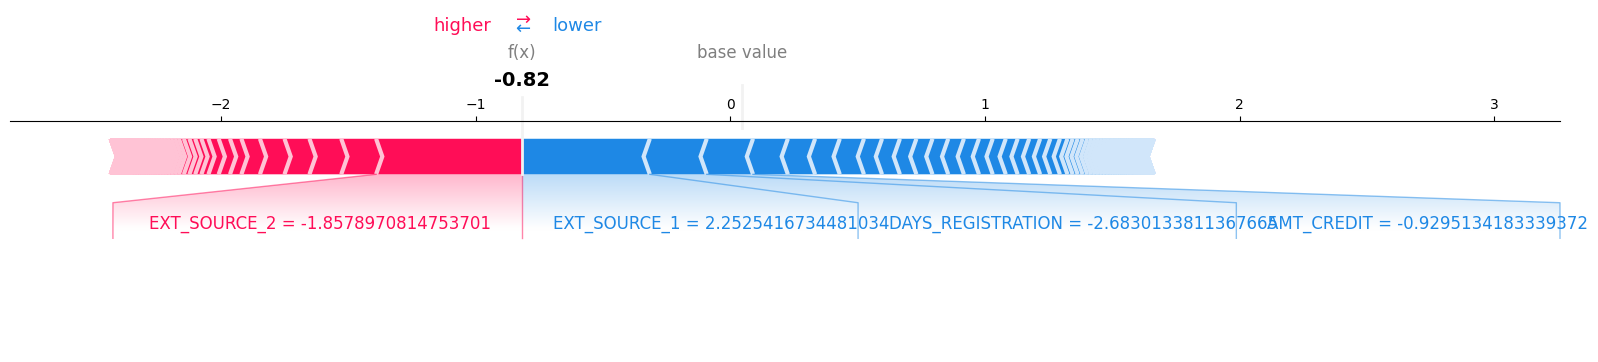

In [52]:
# Local explanation for a single applicant
shap.initjs()
i = 0
shap.force_plot(
    explainer.expected_value, shap_values[i], X_val_sample_proc[i],
    feature_names=feature_names, matplotlib=True, show=True
)


## 10. Save Artifacts

Save the winning pipeline (preprocessing + model), the chosen threshold, and
the feature list — these are what the Streamlit app (`app/app.py`) loads.

In [53]:
import joblib
from pathlib import Path
import json
from datetime import datetime

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(best_xgb_model, MODEL_DIR / "credit_risk_pipeline.joblib")

metadata = {
    "model_name": "XGBoost (tuned)",
    "trained_at": datetime.utcnow().isoformat(),
    "threshold": float(best_threshold),
    "roc_auc_val": float(results["XGBoost (tuned)"]["roc_auc"]),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
}
with open(MODEL_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved model pipeline and metadata to", MODEL_DIR.resolve())


Saved model pipeline and metadata to /content/models


/tmp/ipykernel_1709/3091273578.py:13: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "trained_at": datetime.utcnow().isoformat(),


## 11. Conclusion & Next Steps

- Best classical model: **XGBoost (tuned)** — see comparison table above.
- The MLP provides a meaningful deep-learning upgrade; compare its ROC-AUC/PR-AUC
  against XGBoost to decide which to ship as the champion model.
- Explainability via SHAP surfaces the top global and local risk drivers.
- Next: run `app/app.py` (Streamlit) locally or on a cloud host, pointing it
  at `models/credit_risk_pipeline.joblib` and `models/metadata.json`.
- See the accompanying `reports/final_report_template.md` for the write-up
  structure required by the roadmap (Executive Summary → References).
